In [1]:
# Imports
%load_ext autoreload
%autoreload 2

import numpy as np 
import matplotlib.pyplot as plt 
import matplotlib.ticker as ticker
import solar_utils as su

In [2]:
# Carrega FITS
stokes, header = su.load_solar_fits('Eventos/combined_20100704_145053.fits')

# Normalização
stokes_norm, I_qs, mapa_intensidade = su.normalize_stokes_continuum(stokes)

# Calibração Espectral via Header
ll = su.generate_wavelength_axis(stokes_norm, header)

# Calibração Espacial via Header
shape_y, shape_x = stokes.shape[0], stokes.shape[1]
_, _, map_extent, _ = su.get_physical_scales(shape_x, shape_y, header)

## Análise de um Pixel Isolado: A Física da Aproximação de Campo Fraco (WFA)

Para compreender visualmente como os mapas magnéticos são construídos, podemos isolar um único pixel da nossa região ativa e analisar os seus perfis de Stokes. A Aproximação de Campo Fraco (WFA) baseia-se em relações lineares fundamentais entre os parâmetros de polarização e as derivadas do perfil de intensidade ($I$):

1. **Campo Longitudinal ($B_{LOS}$):** O perfil de polarização circular (Stokes $V$) tem a mesma forma da primeira derivada da Intensidade ($\partial I / \partial \lambda$). A inclinação dessa reta nos dá a magnitude e o sentido de $B_{LOS}$.
2. **Campo Transversal ($B_{T}$):** A polarização linear total ($L = \sqrt{Q^2 + U^2}$) é proporcional à magnitude da segunda derivada da Intensidade ($|\partial^2 I / \partial \lambda^2|$).
3. **Ângulo Azimutal ($\chi$):** É calculado diretamente através da razão entre os perfis de Stokes $U$ e $Q$ no ponto exato onde a polarização linear ($L$) atinge o seu valor máximo.

O código abaixo extrai um pixel da região da mancha solar e realiza a regressão linear numérica para estes três componentes, provando a eficácia do método.

### Configuração do Pixel

In [3]:
x_pix, y_pix = 233, 154

# Constantes físicas da linha 6301.5 Å
lam0 = 6301.5
g_eff = 1.667
G_bar = 2.517
k = 4.6686 * (10**-13) 

# DEFINIÇÃO DINÂMICA DA JANELA ESPECTRAL
i_centro = np.argmin(np.abs(ll - lam0))
limite_esq = max(0, i_centro - 14)
limite_dir = min(len(ll), i_centro + 15) 
janela = slice(limite_esq, limite_dir)

l_window = ll[janela]

### Mapa no continuo

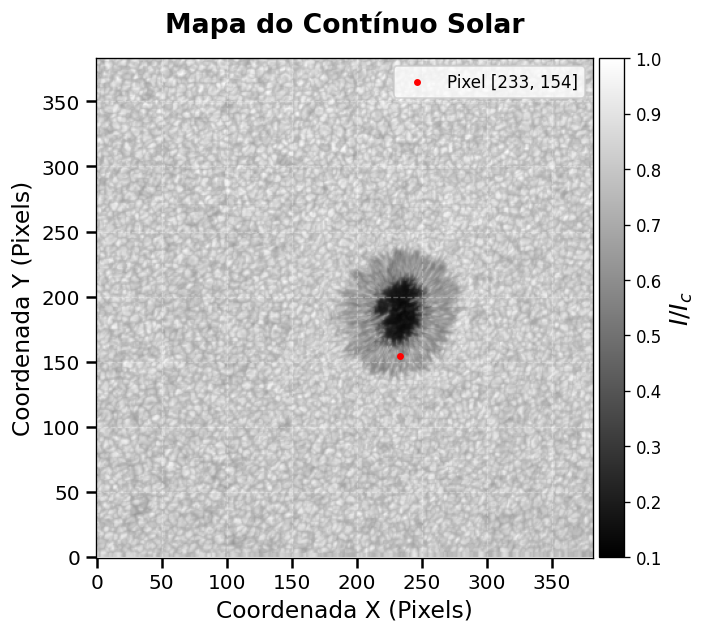

In [4]:
fig, ax = plt.subplots(figsize=(6, 6), dpi=120)

im = ax.imshow(
    mapa_intensidade,  
    origin='lower', 
    cmap='gray', 
    vmin=0.1,  # Contraste melhorado para manchas
    vmax=1, 
    aspect='equal'
) 

# MARCADOR DO PIXEL 
# Usa o x_pix e y_pix definidos anteriormente
# ax.plot(x_pix, y_pix, marker='.', color='red', markersize=3, label=f'Pixel [{x_pix}, {y_pix}]')
# No scatter, o tamanho do marcador é definido pelo argumento 's'
ax.scatter(x_pix, y_pix, color='red', s=10, label=f'Pixel [{x_pix}, {y_pix}]')
ax.legend()

# Estética e Títulos
ax.set_title("Mapa do Contínuo Solar", fontsize=16, weight='bold', pad=15)
ax.set_xlabel("Coordenada X (Pixels)", fontsize=14)
ax.set_ylabel("Coordenada Y (Pixels)", fontsize=14)

# Ajuste Fino dos Eixos
ax.tick_params(axis='both', which='major', labelsize=12, length=6, width=1.5)

# Grade
ax.grid(True, which='major', color='white', linestyle='--', alpha=0.3)
ax.grid(True, which='minor', color='white', linestyle=':', alpha=0.1)

cbar = fig.colorbar(im, shrink=0.76, pad=0.01)
cbar.set_label(r'$I/I_c$', fontsize=15)

plt.tight_layout()
plt.show()

### Perfil de Stokes para o pixel selecionado

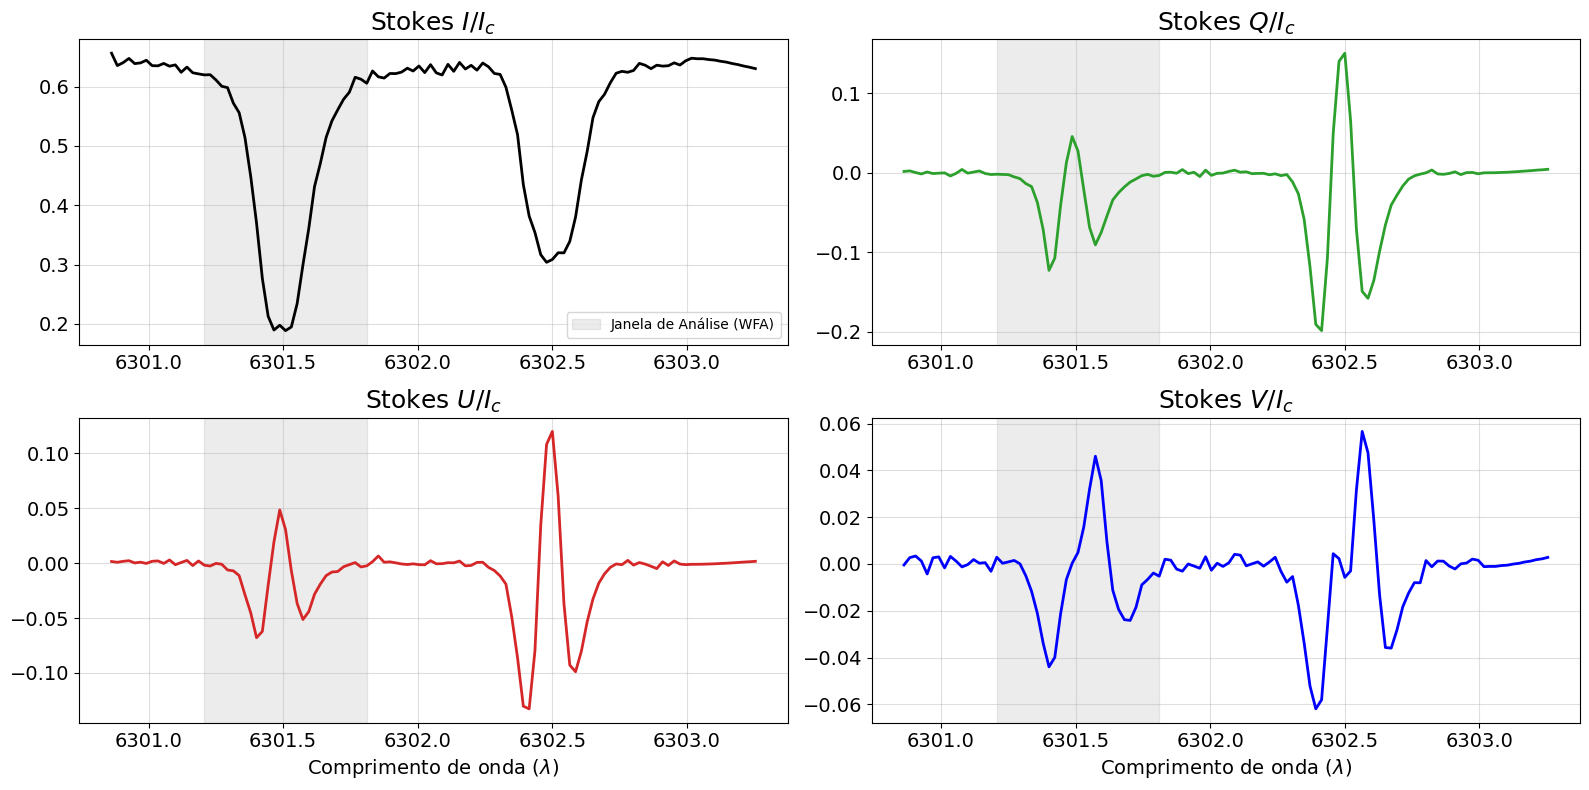

In [5]:
fig, axs = plt.subplots(2, 2, figsize=[16, 8], dpi=100)

# Limites da janela espectral usada no cálculo WFA (para o sombreamento)
lam_start = ll[janela][0]
lam_end = ll[janela][-1]

# Cores distintas para cada perfil para melhor visualização
cores = ['black', '#2ca02c', '#d62728', 'blue']
titulos = ["Stokes $I/I_c$", "Stokes $Q/I_c$", "Stokes $U/I_c$", "Stokes $V/I_c$"]

# Loop para plotar os 4 quadrantes
for i in range(4):
    row, col = divmod(i, 2)
    ax = axs[row, col]
    
    # Plota o perfil completo
    ax.plot(ll, stokes_norm[y_pix, x_pix, i, :], color=cores[i], linewidth=2)
    
    # Destaca a região (janela) que será usada pela WFA
    ax.axvspan(lam_start, lam_end, color='gray', alpha=0.15, label='Janela de Análise (WFA)')
    
    ax.grid(True, alpha=0.4)
    ax.set_title(titulos[i], fontsize=18)
    ax.tick_params(axis='both', which='major', labelsize=14)
    
    # Coloca rótulos de X apenas nos gráficos de baixo
    if row == 1:
        ax.set_xlabel(r"Comprimento de onda ($\lambda$)", fontsize=14)
        
    # Adiciona a legenda apenas no primeiro gráfico para não poluir
    if i == 0:
        ax.legend(fontsize=10)

#fig.suptitle(f"Perfis de Stokes para o Pixel [X={x_pix}, Y={y_pix}]", fontsize=20, weight='bold', y=1.01)
fig.tight_layout()

plt.savefig(f'Figuras/Stokes_IQUV_ [X={x_pix}, Y={y_pix}].png', dpi=600, transparent=True, bbox_inches='tight',pad_inches=0.1)
plt.show()

### Análise de WF para o pixel selecionado

### Inferência do Vetor Magnético Local via Aproximação de Campo Fraco (WFA)

Nesta etapa, aplicamos o formalismo matemático da Aproximação de Campo Fraco para extrair as três componentes fundamentais do vetor de campo magnético ($B_{LOS}$, $B_T$ e $\chi$) para o píxel selecionado. O método baseia-se na correlação linear entre os sinais de polarização (Stokes $Q, U, V$) e as derivadas numéricas do perfil de intensidade (Stokes $I$).

**1. Campo Magnético Longitudinal ($B_{LOS}$)**
No regime de campo fraco, a polarização circular (Stokes $V$) escala linearmente com a primeira derivada espectral da intensidade:
$$V(\lambda) \approx - (k \lambda_0^2 g_{\mathrm{eff}} B_{LOS}) \frac{\partial I}{\partial \lambda}$$
* **Implementação:** Calculamos o gradiente numérico discreto $\partial I / \partial \lambda$ e aplicamos um ajuste linear (`np.polyfit` de grau 1). O coeficiente angular da reta ($m_{blos}$) contém a componente $B_{LOS}$, que é posteriormente isolada dividindo-se pelas constantes atômicas do modelo.

**2. Campo Magnético Transversal ($B_T$)**
A polarização linear total $L = \sqrt{Q^2 + U^2}$, gerada pelo efeito Zeeman transversal (um fenômeno de segunda ordem), é proporcional ao valor absoluto da segunda derivada da intensidade:
$$L(\lambda) \approx \frac{\bar{G} (k \lambda_0^2 B_T)^2}{4} \left| \frac{\partial^2 I}{\partial \lambda^2} \right|$$
* **Implementação:** Calculamos a segunda derivada espectral numéricamente e realizamos uma nova regressão linear. Como $B_T$ está elevado ao quadrado na teoria, extraímos a sua magnitude aplicando a raiz quadrada sobre a inclinação da reta ajustada ($m_{bt}$) ponderada pelas constantes atômicas ($\bar{G}$).

**3. Azimute Magnético ($\chi$)**
A orientação vetorial transversal no plano do céu (azimute) é independente dos alargamentos termodinâmicos e da intensidade do campo, dependendo estritamente da razão entre as componentes de polarização linear:
$$\chi = \frac{1}{2} \arctan \left( \frac{U}{Q} \right)$$
* **Implementação:** Para evitar instabilidades matemáticas provocadas pela divisão de ruído de fundo nas alas da linha, isolamos o índice espectral onde o sinal de polarização linear é máximo (`idx_max_L`). Aplicamos a função `np.arctan2` nestes pontos de máxima relação sinal-ruído para garantir a resolução correta dos quadrantes trigonométricos e convertemos o resultado para graus.

In [6]:
i_prof = stokes_norm[x_pix, y_pix, 0, janela]  
q_prof = stokes_norm[x_pix, y_pix, 1, janela]
u_prof = stokes_norm[x_pix, y_pix, 2, janela]
v_prof = stokes_norm[x_pix, y_pix, 3, janela]

# CAMPO LONGITUDINAL (B_LOS)
dl = np.gradient(l_window)
dI_dl = np.gradient(i_prof) / dl

# Adiciona cov=True para obter a matriz de covariância
coeffs_blos, cov_blos = np.polyfit(dI_dl, v_prof, 1, cov=True)
m_blos, c_blos = coeffs_blos

# Erro da inclinação (raiz quadrada da variância na diagonal da matriz)
err_m_blos = np.sqrt(cov_blos[0, 0])

# R^2 de Pearson
r2_blos = np.corrcoef(dI_dl, v_prof)[0, 1]**2

denominador_blos = k * (lam0**2) * g_eff
B_los = -m_blos / denominador_blos
err_B_los = err_m_blos / denominador_blos  # Propagação de erro direta (linear)

# CAMPO TRANSVERSAL (B_T)
L_prof = np.sqrt(q_prof**2 + u_prof**2)
d2I_dl2 = np.gradient(dI_dl) / dl
abs_d2I_dl2 = np.abs(d2I_dl2)

coeffs_bt, cov_bt = np.polyfit(abs_d2I_dl2, L_prof, 1, cov=True)
m_bt, c_bt = coeffs_bt

err_m_bt = np.sqrt(cov_bt[0, 0])
r2_bt = np.corrcoef(abs_d2I_dl2, L_prof)[0, 1]**2

denominador_bt = G_bar * (lam0**2 * k)**2
B_T = np.sqrt(np.abs(m_bt) * 4 / denominador_bt)

# Propagação de erro para função de raiz quadrada: (1/2) * B_T * (erro_m / m)
err_B_T = 0.5 * B_T * (err_m_bt / np.abs(m_bt))

# ÂNGULO AZIMUTAL (Chi)
idx_max_L = np.argmax(L_prof)
Q_max = q_prof[idx_max_L]
U_max = u_prof[idx_max_L]

chi_rad = 0.5 * np.arctan2(U_max, Q_max)
chi_deg = (np.degrees(chi_rad) + 90) % 180  

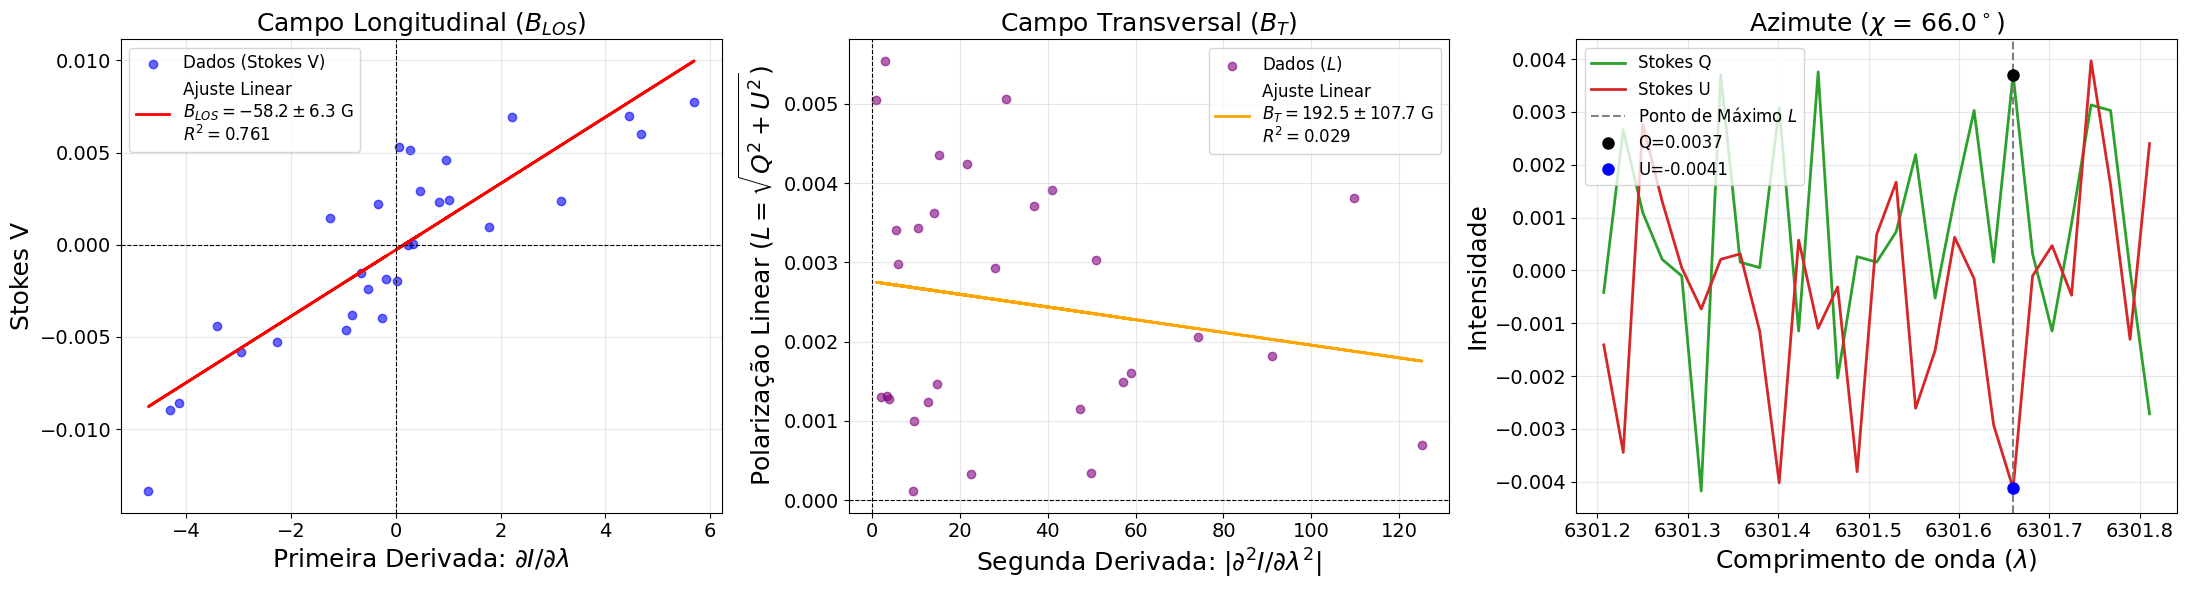

In [7]:
# PLOTAGEM DIDÁTICA DO PIXEL
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(22, 6))

ax1.scatter(dI_dl, v_prof, color='blue', alpha=0.6, label='Dados (Stokes V)')
# Adicionando o erro e o R^2 na legenda
# legenda_blos = f'Ajuste Linear\n$B_{{LOS}} = {B_los:.1f} \pm {err_B_los:.1f}$ G\n$R^2 = {r2_blos:.3f}$'
legenda_blos = f'Ajuste Linear\n$B_{{LOS}} = {B_los:.1f} \\pm {err_B_los:.1f}$ G\n$R^2 = {r2_blos:.3f}$'
ax1.plot(dI_dl, m_blos * dI_dl + c_blos, color='red', linewidth=2, label=legenda_blos)
ax1.set_title(r"Campo Longitudinal ($B_{LOS}$)", fontsize=18)
ax1.set_xlabel(r"Primeira Derivada: $\partial I / \partial \lambda$", fontsize=18)
ax1.set_ylabel("Stokes V", fontsize=18)
ax1.tick_params(axis='both', which='major', labelsize=14)
ax1.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax1.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax1.legend(fontsize=12)
ax1.grid(True, alpha=0.3)

ax2.scatter(abs_d2I_dl2, L_prof, color='purple', alpha=0.6, label=r'Dados ($L$)')
# Adicionando o erro e o R^2 na legenda
# legenda_bt = f'Ajuste Linear\n$B_{{T}} = {B_T:.1f} \pm {err_B_T:.1f}$ G\n$R^2 = {r2_bt:.3f}$'
legenda_bt = f'Ajuste Linear\n$B_{{T}} = {B_T:.1f} \\pm {err_B_T:.1f}$ G\n$R^2 = {r2_bt:.3f}$'
ax2.plot(abs_d2I_dl2, m_bt * abs_d2I_dl2 + c_bt, color='orange', linewidth=2, label=legenda_bt)
ax2.set_title(r"Campo Transversal ($B_{T}$)", fontsize=18)
ax2.set_xlabel(r"Segunda Derivada: $|\partial^2 I / \partial \lambda^2|$", fontsize=18)
ax2.set_ylabel(r"Polarização Linear ($L = \sqrt{Q^2+U^2}$)", fontsize=18)
ax2.tick_params(axis='both', which='major', labelsize=14)
ax2.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax2.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax2.legend(fontsize=12)
ax2.grid(True, alpha=0.3)

ax3.plot(l_window, q_prof, color='#2ca02c', linewidth=2, label='Stokes Q')
ax3.plot(l_window, u_prof, color='#d62728', linewidth=2, label='Stokes U')
ax3.axvline(l_window[idx_max_L], color='grey', linestyle='--', label=f'Ponto de Máximo $L$')
ax3.plot(l_window[idx_max_L], Q_max, 'ko', markersize=8, label=f'Q={Q_max:.4f}')
ax3.plot(l_window[idx_max_L], U_max, 'bo', markersize=8, label=f'U={U_max:.4f}')
ax3.set_title(rf"Azimute ($\chi$ = {chi_deg:.1f}$^\circ$)", fontsize=18)
ax3.set_xlabel(r"Comprimento de onda ($\lambda$)", fontsize=18)
ax3.set_ylabel("Intensidade", fontsize=18)
ax3.tick_params(axis='both', which='major', labelsize=14)
ax3.xaxis.set_major_locator(ticker.MultipleLocator(0.1))
ax3.xaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))
ax3.legend(loc='upper left', fontsize=12)
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('Figuras/Ajustes_WFA_pixel_com_erros.png', dpi=600, transparent=True, bbox_inches='tight',pad_inches=0.1)

plt.show()
# RESUMO NO TERMINAL
# print(f"Resumo para o Pixel [X={x_pix}, Y={y_pix}]:")
# print(f'Ajuste Linear\n$B_{{LOS}} = {B_los:.1f} \\pm {err_B_los:.1f}$ G\n$R^2 = {r2_blos:.3f}$')
# print(f'Ajuste Linear\n$B_{{T}} = {B_T:.1f} \\pm {err_B_T:.1f}$ G\n$R^2 = {r2_bt:.3f}$')
# print(f"- Azimute: {chi_deg:.1f} Graus")

## Análise para todo o evento: A Física da Aproximação de Campo Fraco (WFA)

### Inversão Vetorial Global da Região Ativa (Pipeline WFA)

Após a validação física e estatística do método em píxeis isolados, expandimos a aplicação da Aproximação de Campo Fraco para todo o campo de visão (FOV) da observação. 

A célula abaixo orquestra o processamento completo do cubo de dados através da função `run_wfa_pipeline`. Esta etapa foi otimizada para executar o cálculo numérico de forma vetorizada, garantindo máxima eficiência computacional.

**1. Seleção Dinâmica da Linha Espectral:**
A variável `linha` define qual componente do dubleto de Ferro será analisada. O pipeline busca automaticamente as constantes atômicas fundamentais (fator de Landé efetivo $g_{\mathrm{eff}}$, fator transversal $\bar{G}$ e $\lambda_0$) predefinidas no dicionário do `solar_utils.py`. Isso permite alternar facilmente entre o Fe I 6301.5 Å e o Fe I 6302.5 Å para estudos comparativos de altura de formação.

**2. Rastreamento Dinâmico do Núcleo (Janela de 14 pontos):**
O parâmetro `tamanho_janela=14` garante que, para cada um dos milhares de píxeis do mapa, o algoritmo recalcule o índice de mínima intensidade (fundo do poço da linha de absorção). Isso cria uma janela de 29 pontos espectrais perfeitamente centrada no núcleo real da linha local, corrigindo os deslocamentos provocados pelo efeito Doppler (como o fluxo de Evershed) antes do cálculo numérico das derivadas.

**3. Geração dos Magnetogramas:**
O resultado da inversão ($B_{LOS}$, $B_T$ e $\chi$) é submetido à rotina de plotagem `plot_magnetic_maps`. Esta função gera o painel diagnóstico final, aplicando o recorte espacial (zoom), o rigor das coordenadas em *arcsec* e as paletas de cores calibradas (divergente para o campo longitudinal e sequencial para a magnitude transversal), fundamentais para a interpretação topológica das estruturas da umbra e penumbra.

In [8]:
# Executa a aproximação para todos os pixels de uma só vez na linha desejada
linha = '6301' # Pode trocar facilmente por '6302'
Blos, Bt, Chi = su.run_wfa_pipeline(stokes_norm, ll, linha_escolhida=linha, tamanho_janela=14)

print(f"B_LOS Mínimo: {Blos.min():.2f} Gauss | B_LOS Máximo: {Blos.max():.2f} Gauss")

Analisando a linha 6301.5 Å | g_eff = 1.667 | G_bar = 2.517
B_LOS Mínimo: -4415.18 Gauss | B_LOS Máximo: 1545.28 Gauss


## Mapas para o campo Longitudinal ($B_{LOS}$), Campo Transversal ($B_{T}$) e Ângulo Azimutal ($\chi$) 

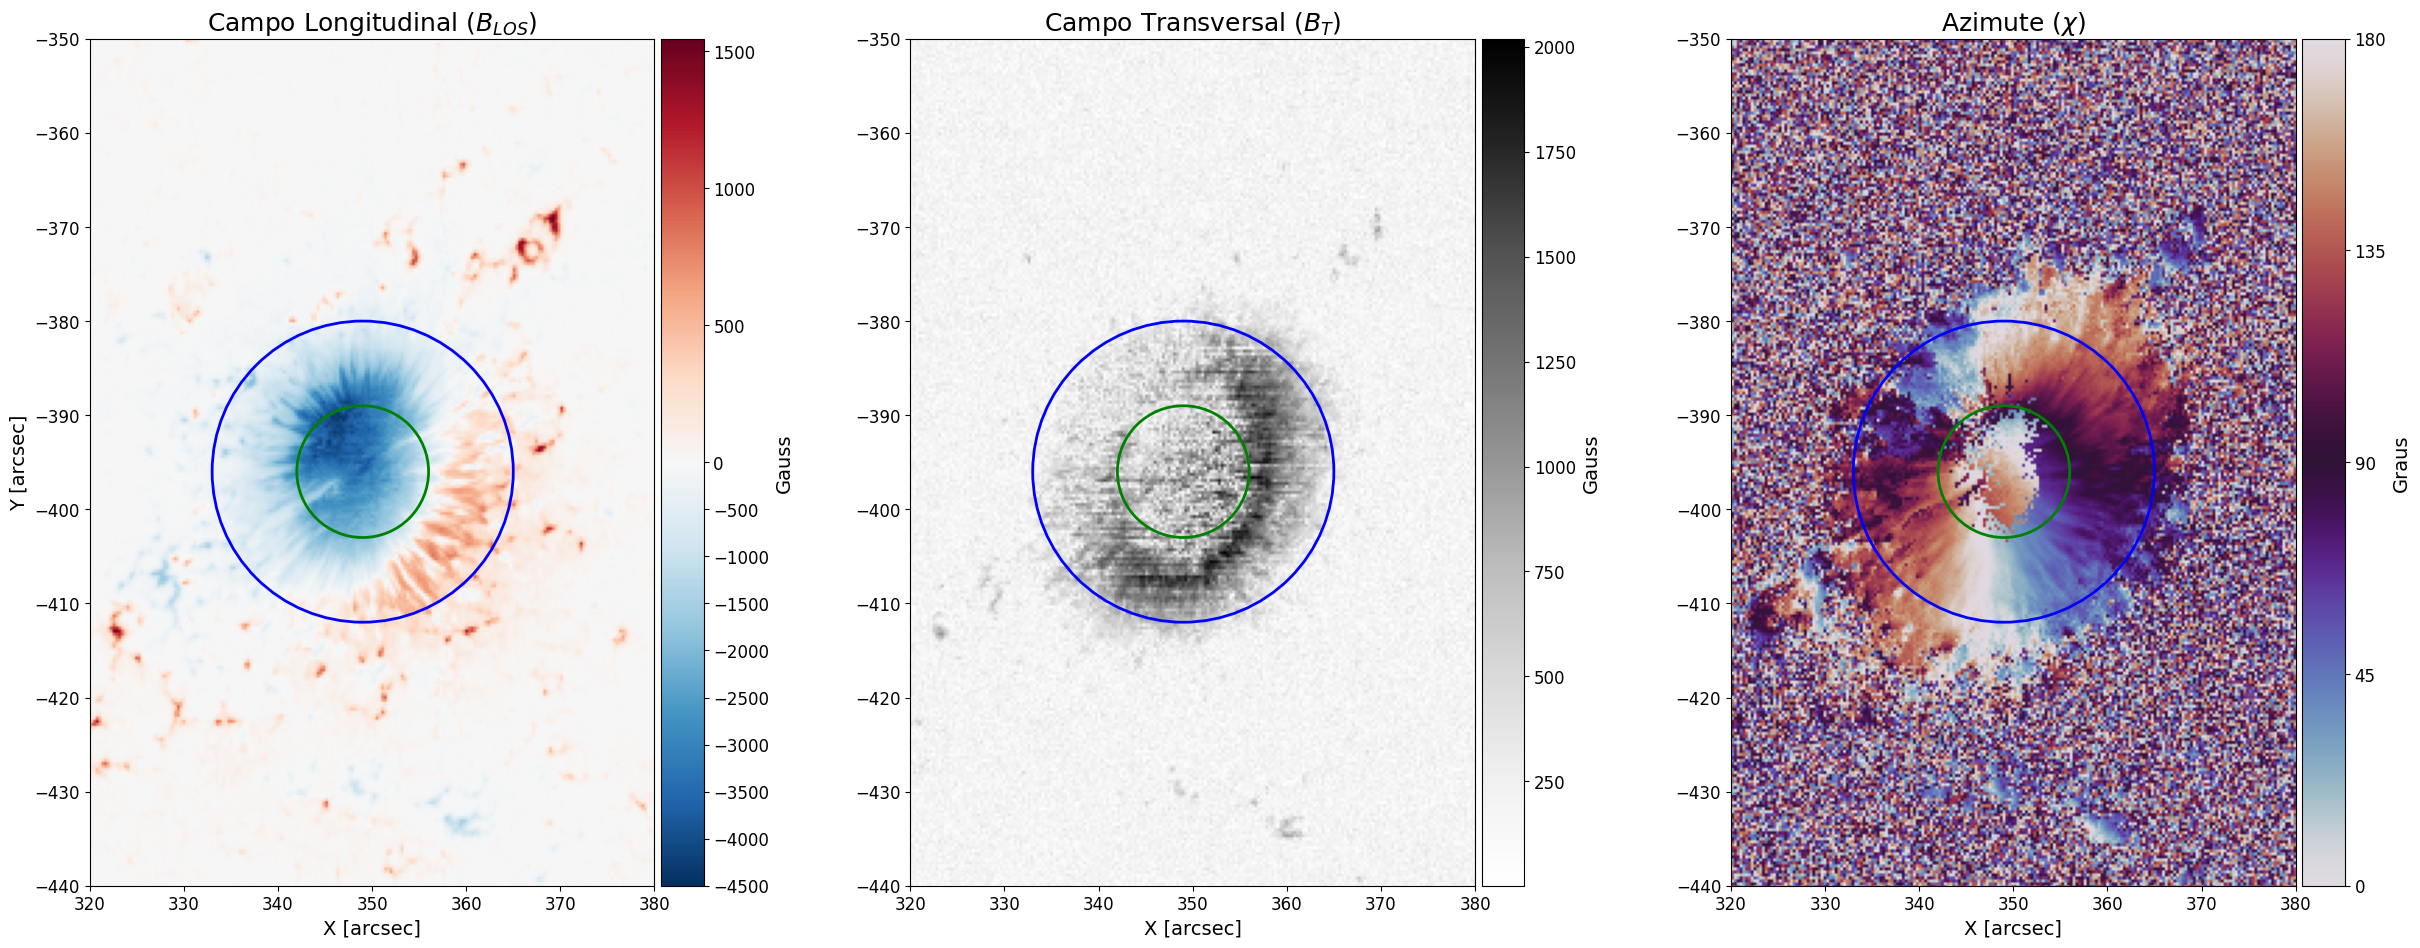

In [9]:
# Plota os gráficos com o zoom, os círculos (umbra/penumbra) e barra divergente exata.
# Você pode salvar ativando save_fig=True
fig = su.plot_magnetic_maps(Blos, Bt, Chi, map_extent, save_fig=False, filename=f'Figuras/Magnetograma_{linha}.png')
plt.show()